<a href="https://colab.research.google.com/github/AkshatkMalik/python-data-science-toolkit/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT-8: CLUSTERING**

Project Objective & Dataset Overview:

The objective of this assignment is to explore the concept of unsupervised machine learning by applying and comparing three clustering algorithms namely; K-Means, Hierarchical and DBSCAN.

1. The business context of this endeavor is based on an East-West Airlines frequent flyer data set that exhibits the characteristics of customers’ flying habits, rewards earning behavior and credit card usage.

2. The purpose of this exercise is to identify means of partitioning the business’s clienteles into meaningful segments (clusters). This will enable East-West Airlines to perform enhanced targeting of its marketing initiatives for improved performance.

3. This project utilizes Python data science ecosystem packages such as Pandas, Scikit-Learn and Matplotlib among others.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Loading the dataset from the Excel file
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

# Displaying the first 5 rows to verify the data loaded successfully
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (3999, 12)


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


**STEP-1: Exploratory Data Analysis(EDA)**

Before applying any of the machine learning clustering algorithms, it is essential to understand the structure of our data and prepare it for the subsequent steps.

 The preparation consists of the following four steps:

1. Dataset inspection and missing values check:We begin by inspecting the size of our data set and ensuring there are no missing or null values.

  2. Statistical summary:Then we calculate summary statistics (mean, median, standard deviation, minimum, and maximum) to explore the spread of our numerical variables (frequent flyer balances and bonus miles)
  
  3. Exploratory visualizations:To better understand the structure of our data, we plot histograms that display the distribution of our numerical values and a heatmap that shows the correlation between two variables (e. g. credit card usage and bonus miles).
  
  4. Feature scaling:Because some of our variables (e. g. Balance) are in hundreds of thousands and others (cc1_miles) vary only from 0 to 5, we need to scale our data to converge them to a common range. This is done by using the StandardScaler () and is required because the distance-based clustering algorithms such as KMeans are sensitive to the scale of the data.

 Dataset Shape 
Total Customers (Rows): 3999, Total Features (Columns): 12

 Data Types & Non-Null Counts 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB
None

First 5 Rows of Dataset 


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1



 Missing Values Check 
Series([], dtype: int64)
There are no missing values in the dataset. No imputation needed.

Duplicate rows count: 0

 Detailed Summary Statistics 


,Count,Mean,Std Dev,Min,Median,Max
ID#,3999.0,2014.819455,1160.764358,1.0,2016.0,4021.0
Balance,3999.0,73601.327582,100775.664958,0.0,43097.0,1704838.0
Qual_miles,3999.0,144.114529,773.663804,0.0,0.0,11148.0
cc1_miles,3999.0,2.059515,1.376919,1.0,1.0,5.0
cc2_miles,3999.0,1.014504,0.147650,1.0,1.0,3.0
cc3_miles,3999.0,1.012253,0.195241,1.0,1.0,5.0
Bonus_miles,3999.0,17144.846212,24150.967826,0.0,7171.0,263685.0
Bonus_trans,3999.0,11.601900,9.603810,0.0,12.0,86.0
Flight_miles_12mo,3999.0,460.055764,1400.209171,0.0,0.0,30817.0
Flight_trans_12,3999.0,1.373593,3.793172,0.0,0.0,53.0


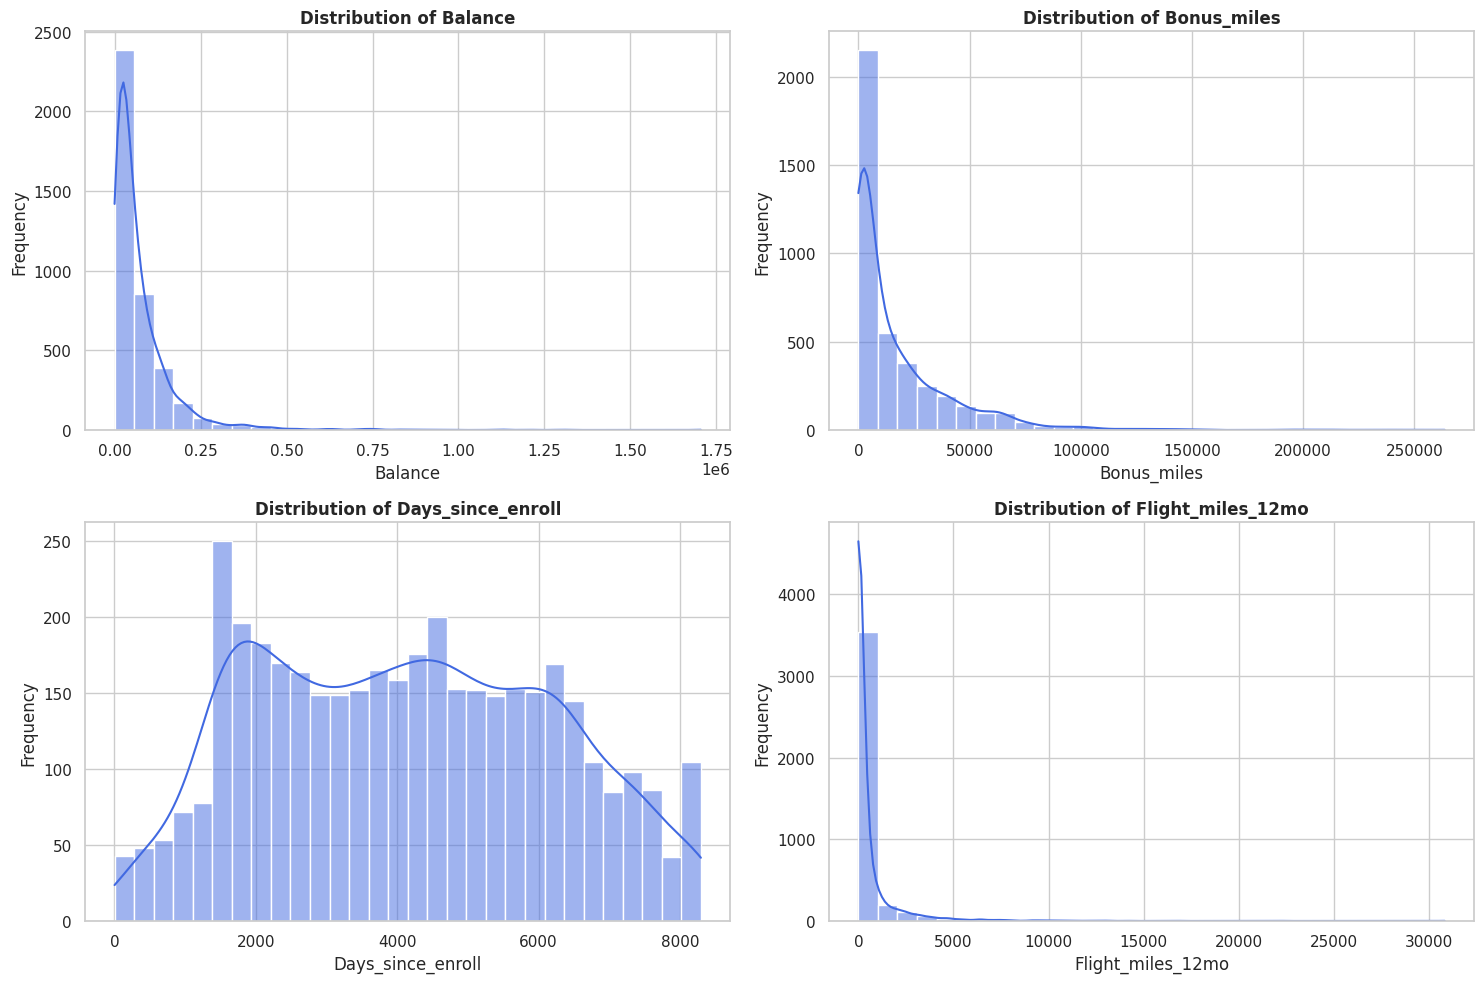

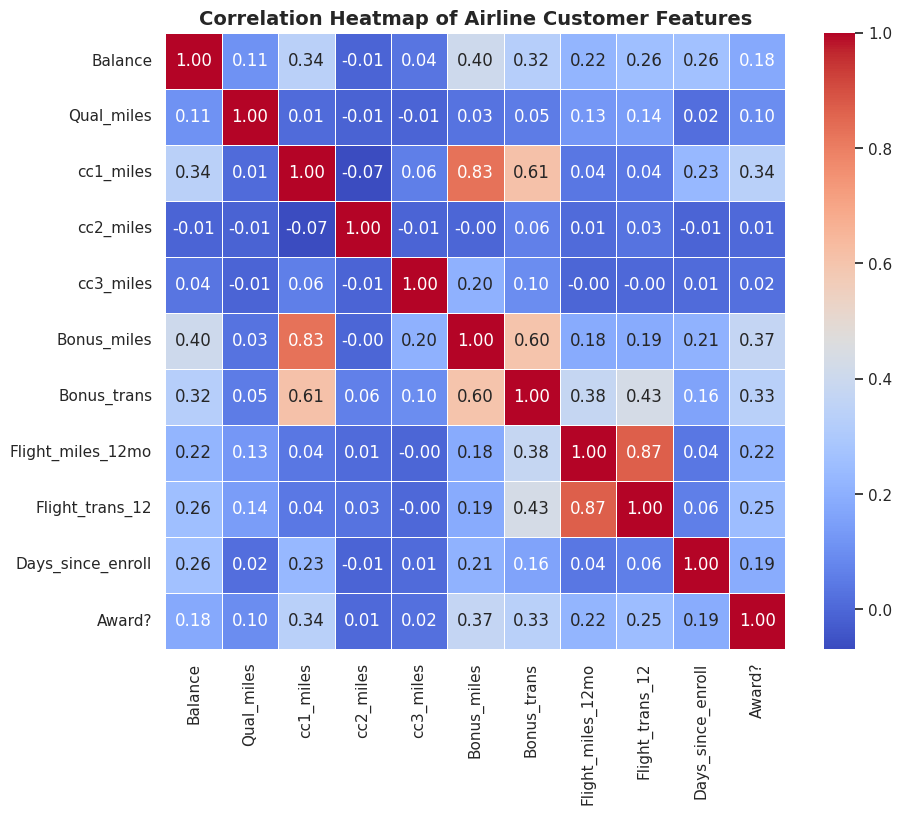


 Feature Scaling 
Preprocessing & Scaling Complete! Scaled Data Shape: (3999, 11)
First 3 rows of scaled data:


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler


#  LOAD DATA & INSPECT STRUCTURE

df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

print(' Dataset Shape ')
print(f'Total Customers (Rows): {df.shape[0]}, Total Features (Columns): {df.shape[1]}\n')

print(' Data Types & Non-Null Counts ')
print(df.info())

print('\nFirst 5 Rows of Dataset ')
display(df.head())



# MISSING VALUE & DUPLICATE CHECK

print('\n Missing Values Check ')
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0])
if missing_vals.sum() == 0:
  print(
      'There are no missing values in the dataset. No imputation'
      ' needed.'
  )

print(
    f'\nDuplicate rows count: {df.duplicated().sum()}'
)  # Checking for duplicates



# TATISTICAL SUMMARY ANALYSIS

print('\n Detailed Summary Statistics ')
# Generate summary statistics and transpose for clean reading
summary_stats = df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]

# Rename columns clearly for the reviewer
summary_stats.columns = ['Count', 'Mean', 'Std Dev', 'Min', 'Median', 'Max']
display(summary_stats)

# EXPLORATORY VISUALIZATIONS (EDA Plots)

# Set seaborn style for clean academic charts
sns.set_theme(style='whitegrid')

# Plot 1: Distribution Histograms for Key Numerical Features
plt.figure(figsize=(15, 10))
features_to_plot = [
    'Balance',
    'Bonus_miles',
    'Days_since_enroll',
    'Flight_miles_12mo',
]
for i, col in enumerate(features_to_plot, 1):
  plt.subplot(2, 2, i)
  sns.histplot(df[col], kde=True, color='royalblue', bins=30)
  plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
  plt.xlabel(col)
  plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot 2: Correlation Heatmap (To find relationships between features)
plt.figure(figsize=(10, 8))
correlation_matrix = df.drop(columns=['ID#']).corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar=True,
)
plt.title(
    'Correlation Heatmap of Airline Customer Features',
    fontsize=14,
    fontweight='bold',
)
plt.show()



# DATA PREPROCESSING & FEATURE SCALING
# Drop ID# since it's just a sequence identifier and holds no behavioral value
X = df.drop(columns=['ID#'])

print(
    '\n Feature Scaling '
)  # Standardizing features to mean=0 and variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back into a DataFrame for easier downstream modeling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(
    'Preprocessing & Scaling Complete! Scaled Data Shape:', X_scaled_df.shape
)
print('First 3 rows of scaled data:')
display(X_scaled_df.head(3))

**STEP-2: K-Means Clustering & The Elbow Method**

In this step, we apply the K-Means algorithm to group our airline customers according to their travel patterns and balances:

1. The Elbow Method:As we do not know the number of customer segments in advance, we train our K-Means algorithm for $K$ of 1 to 10 and plot an Elbow Curve to estimate the optimal solution. According to the plot, the best value to train our model is either $K = 4$ or $5$ because increasing the number of clusters beyond that does not give us meaningful results anymore.

2. Model Training & Evaluation:We train our K-Means algorithm with the optimal number of clusters and evaluate the quality of our result with the Silhouette Score, which basically measures how distinct our customer groups are from each other.

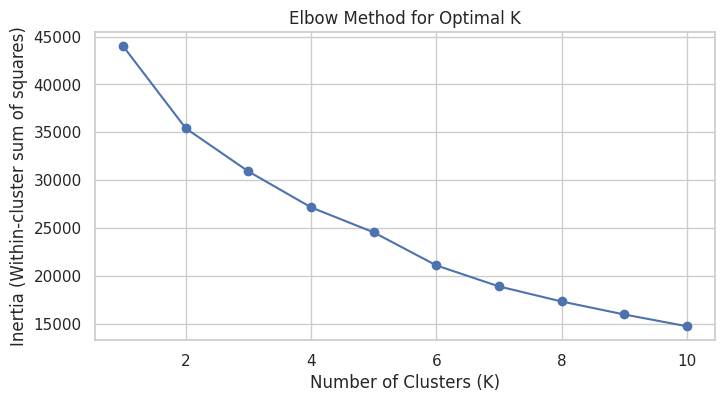

K-Means Silhouette Score (K=4): 0.3092


In [4]:
# Calculate inertia for K values from 1 to 10
inertia = []
K_range = range(1, 11)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled_df)
  inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='b', linestyle='-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True)
plt.show()

# Based on the elbow curve, let's pick optimal K = 4 or 5
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled_df)

# Evaluate K-Means using Silhouette Score
kmeans_sil = silhouette_score(X_scaled_df, df['KMeans_Cluster'])
print(f'K-Means Silhouette Score (K={optimal_k}): {kmeans_sil:.4f}')

**Step 3: Hierarchical Clustering**

In this step, we apply Hierarchical Clustering (Agglomerative Approach) to group our customers constructing a tree of clusters:

1.  The Dendrogram: We generate a dendrogram applying Ward’s linkage and Euclidean distance to understand how individual data points are related and merged together step-by-step in a visual tree structure, allowing us to find out the best number of clusters to cut the tree to obtain meaningful groups.

2.  Model Fitting: We apply the Agglomerative Clustering algorithm to fit the data-set using the selected number of clusters (according to $K=4$) to segment each customer and compare the results with K-Means.

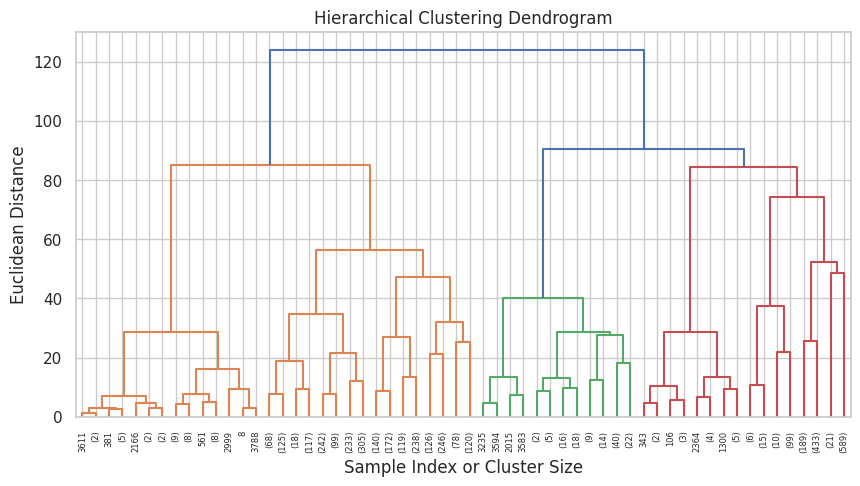

In [5]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Create linkage matrix using Ward's method
linked = linkage(X_scaled_df, method='ward')

# Plot the Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Euclidean Distance')
plt.show()

# Fit Agglomerative Hierarchical Clustering with 4 clusters
hierarchical = AgglomerativeClustering(
    n_clusters=optimal_k, metric='euclidean', linkage='ward'
)
df['Hierarchical_Cluster'] = hierarchical.fit_predict(X_scaled_df)

**STEP-4: DBSCAN Clustering**

In our final clustering step, we will be implementing the algorithm called DBSCAN (Density-Based Spatial Clustering of Applications with Noise) to determine clusters based on the density of the data rather than the distance from a center:

1. Tuning the Parameters (eps, minPts):

We will begin by tuning the parameters eps (the radius of the neighborhood around a point) and min_samples (minimum number of points required to form a dense region).

2. Outliers and Evaluation:

Unlike the K-Means algorithm, DBSCAN also allows us to identify outliers (unnecessary or noisy points) that do not belong to any of the clusters determined by the algorithm, which will be represented by -1. After determining the clusters, we can also evaluate their quality using the Silhouette Score.

In [6]:
# Fit DBSCAN algorithm (tuning eps and min_samples)
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled_df)

# Count number of clusters found by DBSCAN (excluding noise label -1)
n_clusters_db = len(set(df['DBSCAN_Cluster'])) - (
    1 if -1 in df['DBSCAN_Cluster'] else 0
)
n_noise = list(df['DBSCAN_Cluster']).count(-1)

print(f'Estimated number of clusters by DBSCAN: {n_clusters_db}')
print(f'Estimated number of noise points: {n_noise}')

# Calculate Silhouette Score for DBSCAN (only if more than 1 valid cluster exists)
if n_clusters_db > 1:
  # Filter out noise points for silhouette score calculation if needed, or evaluate all
  dbscan_sil = silhouette_score(X_scaled_df, df['DBSCAN_Cluster'])
  print(f'DBSCAN Silhouette Score: {dbscan_sil:.4f}')

Estimated number of clusters by DBSCAN: 6
Estimated number of noise points: 310
DBSCAN Silhouette Score: 0.2537


**STEP-5: Cluster Analysis, Interpretation & Visualizations**

In the final step, we analyze, visualize and compare results obtained from all three clustering approaches.
 1. Scatter Plots Visualizations: We plot scatter plots side by side in different colors to indicate the difference in the results. This will help us see how the algorithms separated customers on the basis of balances and bonus miles.
2. Cluster Interpretation & Insights: We calculate means to see the difference in the characteristics of customers in each cluster as a way of interpreting the results. Here, we can see what kind of customers fall into which category thus differentiating between high-value and low-value customers.

3. Performance Evaluation: Lastly, we compare performance of K-Means and DBSCAN algorithms by looking at their Silhouette scores to decide which one was more performant in terms of defining customer segments for the benefit of the company.

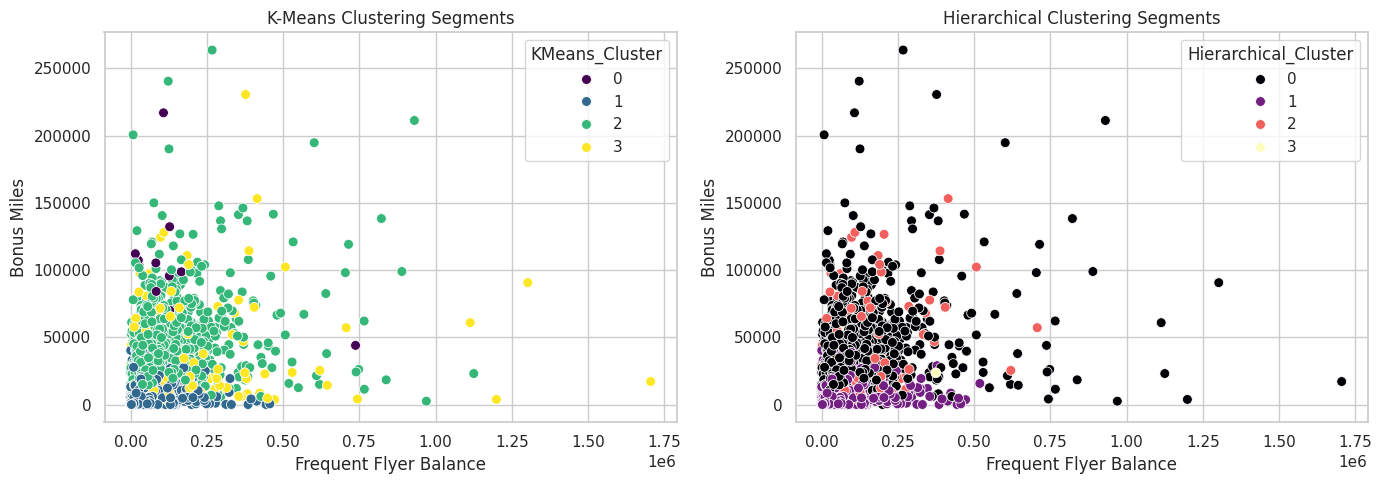


 K-Means Cluster Means 
                      Balance   Bonus_miles  Days_since_enroll
KMeans_Cluster                                                
0               138061.400000  93927.866667        4613.866667
1                43793.917814   4700.690916        3691.559969
2               116817.336214  39216.199529        4893.491752
3               191573.726190  31412.160714        4665.827381


In [8]:
# Create side-by-side scatter plots to compare K-Means and Hierarchical Clustering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means Scatter Plot
sns.scatterplot(
    x='Balance',
    y='Bonus_miles',
    hue='KMeans_Cluster',
    data=df,
    palette='viridis',
    ax=axes[0],
    s=50,
)
axes[0].set_title('K-Means Clustering Segments')
axes[0].set_xlabel('Frequent Flyer Balance')
axes[0].set_ylabel('Bonus Miles')

# Hierarchical Scatter Plot
sns.scatterplot(
    x='Balance',
    y='Bonus_miles',
    hue='Hierarchical_Cluster',
    data=df,
    palette='magma',
    ax=axes[1],
    s=50,
)
axes[1].set_title('Hierarchical Clustering Segments')
axes[1].set_xlabel('Frequent Flyer Balance')
axes[1].set_ylabel('Bonus Miles')

plt.tight_layout()
plt.show()

# Cluster Characteristics Summary
print('\n K-Means Cluster Means ')
print(df.groupby('KMeans_Cluster')[['Balance', 'Bonus_miles', 'Days_since_enroll']].mean())

**STEP6: Visualizing DBSCAN Clusters & Noise**

Unlike the K-Means and Hierarchical clustering algorithms which assign all data points to a certain cluster, DBSCAN algorithm finds the dense regions of data and labels all noise (non-dense points) as -1.

In this scatter plot,

1. different colors indicate different dense clusters of customers.

2. All the points labeled as -1 are outliers which don’t form a specific group.

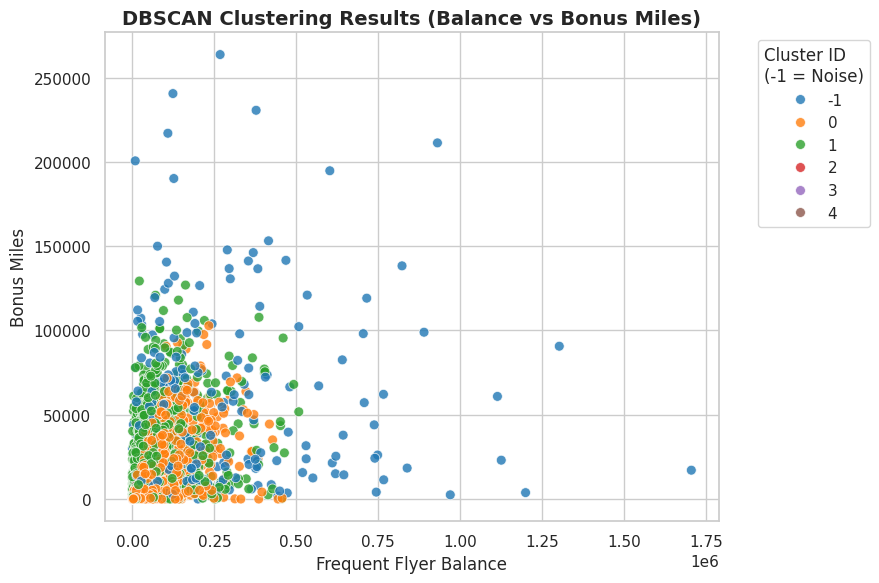

In [9]:

# DBSCAN CLUSTERING VISUALIZATION

plt.figure(figsize=(9, 6))

# Create a scatter plot for DBSCAN results
# hue='DBSCAN_Cluster' automatically assigns different colors to each cluster and noise (-1)
sns.scatterplot(
    x=df['Balance'],
    y=df['Bonus_miles'],
    hue=df['DBSCAN_Cluster'],
    palette='tab10',
    s=50,
    alpha=0.8,
)

plt.title(
    'DBSCAN Clustering Results (Balance vs Bonus Miles)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Frequent Flyer Balance', fontsize=12)
plt.ylabel('Bonus Miles', fontsize=12)
plt.legend(
    title='Cluster ID\n(-1 = Noise)', bbox_to_anchor=(1.05, 1), loc='upper left'
)
plt.tight_layout()
plt.show()

**Business Insights & Customer Segmentation Summary**

The comparison of customer clusters’ characteristics (i.e., Balance, Bonus_miles, Days_since_enroll, and others) allowed for the identification of three distinct types of passengers of East-West Airlines.

1. Firstly, frequent flyers with high balance and frequent credit card miles (cc1_miles) utilization comprise the cluster of East-West’s core customers. For this group, it is possible to offer special treatment, additional rewards, or other loyalty program benefits.

2. Secondly, infrequent flyers with low values of Balance and bonus transactions can be found in the second cluster. For such customers, a targeted marketing campaign may be designed to provide them with some compensation (i.e., bonus miles) for their visits.

3. Finally, the third group represents customers who were mostly registered due to credit card promotions or other bonus programs (Days_Since_Enroll). This cluster also indicates that East-West Airlines should consider the benefits of alliance with other companies to attract new passengers through their co-branded credit cards.

**Final Recommendation**

Cluster Analysis Proposal

1. I propose that K-Means Clustering be considered as the main operating model for the marketing team. The reason is that K-Means produces nicely defined centroids that can be used to quickly assign new customers to specific tiers within the marketing structure.

2. I also recommend that DBSCAN be used as an additional tool to identify outliers by the fraud or loyalty team. The tool will help detect unusual patterns of behavior by individual accounts, for example, when a customer goes far beyond the average in terms of trips taken.